In [3]:
#Data description: The data used was scrapped from hotels on TripAdvisor website

In [4]:
#Importing necessary libraries
import os
import re #for regular expressions
import nltk #for text manipulation
import numpy as np #for complex mathematical operations
#for faster data analysis, data cleaning, and data pre-processing
import pandas as pd
#Required by Matplotlib for visualization
import seaborn as sns
#A data visualization and graphical plotting library
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
#Creating a data-frame to store the reviews
df = pd.read_csv("tripadvisor_hotel_reviews.csv")

In [6]:
#Data-frame shape: The dataset extracted consist of [Rows, Colomns]
df.shape

(20491, 2)

In [7]:
###TEXT PREPARATION

In [8]:
#Creating a data-frame(df) for the negative reviews
df_neg = df.loc[df["Rating"] < 3]
df_neg = df_neg.reset_index(drop = True)

In [9]:
#Creating a data-frame(df) for the neutral reviews
df_neutral = df.loc[df["Rating"] == 3]
df_neutral = df_neutral.reset_index(drop = True)

In [10]:
#Creating a data-frame(df) for the positive reviews
df_pos = df.loc[df["Rating"] > 3]
df_pos = df_pos.reset_index(drop = True)

In [11]:
#creating sentiment column for negative, neutral, and positive classification of reviews
df_neg["Sentiment"] = np.where(df_neg["Rating"] <3,"Negative", "")
df_neutral["Sentiment"] = np.where(df_neutral["Rating"] ==3,"Neutral","")
df_pos["Sentiment"] = np.where(df_pos["Rating"] >3,"Positive", "")

#Concatinating all the reviews
df_all = pd.concat([df_neg, df_neutral, df_pos], axis = 0)
df_all = df_all.reset_index(drop = True)

#Displaying a sample of classified reviews
df_all.head(10)

,Review,Rating,Sentiment
0,ok nothing special charge diamond member hilto...,2,Negative
1,"poor value stayed monaco seattle july, nice ho...",2,Negative
2,horrible customer service hotel stay february ...,1,Negative
3,disappointed say anticipating stay hotel monac...,2,Negative
4,great location need internally upgrade advanta...,2,Negative
5,"noise airconditioner-a standard, arranged stay...",1,Negative
6,good location poor cleanliness warwick hotel g...,2,Negative
7,"bad choice, booked hotel hot wire called immed...",1,Negative
8,warwick bad good reviews warwick shocks staff ...,2,Negative
9,"austin powers decor familiar, hotel seattlewhe...",2,Negative


In [12]:
#Data cleaning process
from nltk.corpus import wordnet

def get_wordnet_pos(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
#Importing necessary libraries
import string
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.tokenize import WhitespaceTokenizer
from nltk.stem import WordNetLemmatizer

#Text cleaning
def clean_text(text):
    # lower text
    text = text.lower()
    # tokenize text and remove puncutation
    text = [word.strip(string.punctuation) for word in text.split(" ")]
    # remove words that contain numbers
    text = [word for word in text if not any(c.isdigit() for c in word)]
    # remove stop words
    stop = stopwords.words('english')
    text = [x for x in text if x not in stop]
    # remove empty tokens
    text = [t for t in text if len(t) > 0]
    # pos tag text
    pos_tags = pos_tag(text)
    # lemmatize text
    text = [WordNetLemmatizer().lemmatize(t[0], get_wordnet_pos(t[1])) for t in pos_tags]
    # remove words with only one letter
    text = [t for t in text if len(t) > 1]
    # join all
    text = " ".join(text)
    return(text)

#clean text data
df_all['Clean_Reviews'] = df_all['Review'].apply(lambda x: clean_text(x))

In [13]:
#DEMONSTRATIONS OF HOW THE DATA CLEANING PROCESS IS EXECUTED
#CONTINUES FROM 12 BELOW

In [14]:
#TEXT LOWERING

from sklearn.feature_extraction.text import CountVectorizer

#DEMONSTRATION TEXT
data_1 = ["Ever just melt into a bed? The room service was so amazing! The staff was so friendly. I’ll be back in a month!."]

#Create the transform
vectorizer = CountVectorizer()
vectorizer.fit(data_1)

print(vectorizer.vocabulary_)

{'ever': 4, 'just': 8, 'melt': 10, 'into': 7, 'bed': 3, 'the': 16, 'room': 12, 'service': 13, 'was': 17, 'so': 14, 'amazing': 0, 'staff': 15, 'friendly': 5, 'll': 9, 'be': 2, 'back': 1, 'in': 6, 'month': 11}


In [15]:
#TEXT TOKENIZATION/SPLITTING INTO WORDS
import nltk
from nltk import word_tokenize

#WORD TOKENIZATION
data = "They had the best room service with spacious rooms and showers, and on arrival, the receptionists were friendly and welcoming."
print(word_tokenize(data))

['They', 'had', 'the', 'best', 'room', 'service', 'with', 'spacious', 'rooms', 'and', 'showers', ',', 'and', 'on', 'arrival', ',', 'the', 'receptionists', 'were', 'friendly', 'and', 'welcoming', '.']


In [16]:
#COUNT OF NUMBER OF APPEARANCES EACH WORD DONE ON THE DEMONSTRTION TEXT
vector = vectorizer.transform(data_1)
print(vector)

  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 6)	1
  (0, 7)	1
  (0, 8)	1
  (0, 9)	1
  (0, 10)	1
  (0, 11)	1
  (0, 12)	1
  (0, 13)	1
  (0, 14)	2
  (0, 15)	1
  (0, 16)	2
  (0, 17)	2


In [17]:
#Punctuations removal from sentences
import string
data = "Ever just melt into a bed? The room service was so amazing! The staff was so friendly. I’ll be back in a month!."
data_1 = [char for char in data if char not in string.punctuation]
print(data_1)

['E', 'v', 'e', 'r', ' ', 'j', 'u', 's', 't', ' ', 'm', 'e', 'l', 't', ' ', 'i', 'n', 't', 'o', ' ', 'a', ' ', 'b', 'e', 'd', ' ', 'T', 'h', 'e', ' ', 'r', 'o', 'o', 'm', ' ', 's', 'e', 'r', 'v', 'i', 'c', 'e', ' ', 'w', 'a', 's', ' ', 's', 'o', ' ', 'a', 'm', 'a', 'z', 'i', 'n', 'g', ' ', 'T', 'h', 'e', ' ', 's', 't', 'a', 'f', 'f', ' ', 'w', 'a', 's', ' ', 's', 'o', ' ', 'f', 'r', 'i', 'e', 'n', 'd', 'l', 'y', ' ', 'I', '’', 'l', 'l', ' ', 'b', 'e', ' ', 'b', 'a', 'c', 'k', ' ', 'i', 'n', ' ', 'a', ' ', 'm', 'o', 'n', 't', 'h']


In [18]:
data_1 = ''.join(data_1)
print(data_1)

Ever just melt into a bed The room service was so amazing The staff was so friendly I’ll be back in a month


In [19]:
#REMOVING STOPWORDS FROM THE TEXTUAL REVIEWS
#These are nothing but word connectors which mostly do not add any value to reviews

from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))
print(stopwords)

{'theirs', 'you', 'these', 'during', 'too', "aren't", 'again', 'between', "mightn't", "that'll", 'how', 'wasn', 'aren', 'yours', "you'll", 'other', "shouldn't", 'yourselves', "isn't", 'myself', 'isn', "don't", 'me', 'did', 'there', "wouldn't", 'with', 'a', 'herself', 'when', 's', 'our', "shan't", 'through', 'after', 'up', 'd', 'o', 'down', 'don', 'why', 'than', 'mustn', 'was', 'weren', 'i', 'my', 'ain', 'while', "it's", 'were', 'from', 'so', 'only', 'whom', 'needn', 'it', 'that', 'over', 'those', 'before', 'at', 'out', 'himself', 'her', "she's", 'any', 'further', 'y', "you've", 'itself', 'm', 'the', 'mightn', 'had', 'being', "you're", "needn't", 'haven', 'above', 'shouldn', "you'd", "wasn't", 'own', 'same', 'off', 'shan', 'to', 'an', 'such', 'by', 'and', 'do', 'on', 'now', 'your', 'of', 't', 'didn', 'which', 'in', 'won', 'are', 'we', 'both', 'can', 'its', 'who', "didn't", "doesn't", 'having', 'doing', 'hadn', 'then', 'should', 'once', 'am', 're', 'but', 'what', 'be', 'has', 'him', 'her

In [20]:
df_arr = df.to_numpy()

In [21]:
#creating a single text 
l = len(df)
polarity_arr = []
subjectivity_arr = []

text_corpus = ""

In [22]:
#Analysis of entire text
for t in df["Review"]:
    text_corpus = text_corpus+"."+t

In [23]:
text_corpus[0:600]

'.nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  .ok no'

In [24]:
len(text_corpus)

14874352

In [25]:
###SENTIMENT DETECTION

In [26]:
#Creating lambda functions to find the polarity and subjectivity of texts
from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

#creating polarity and subjectivity columns for negative reviews
df_neg['polarity'] = df_neg['Review'].apply(pol)
df_neg['subjectivity'] = df_neg['Review'].apply(sub)

#Getting 10 reviews, ratings and sentiments from the negatives dataframe
df_neg.head(10)

,Review,Rating,Sentiment,polarity,subjectivity
0,ok nothing special charge diamond member hilto...,2,Negative,0.214923,0.495009
1,"poor value stayed monaco seattle july, nice ho...",2,Negative,0.241667,0.575000
2,horrible customer service hotel stay february ...,1,Negative,0.006510,0.573611
3,disappointed say anticipating stay hotel monac...,2,Negative,0.160411,0.577007
4,great location need internally upgrade advanta...,2,Negative,0.259375,0.433333
5,"noise airconditioner-a standard, arranged stay...",1,Negative,0.116837,0.516837
6,good location poor cleanliness warwick hotel g...,2,Negative,0.126389,0.623611
7,"bad choice, booked hotel hot wire called immed...",1,Negative,-0.027839,0.578571
8,warwick bad good reviews warwick shocks staff ...,2,Negative,-0.230000,0.633333
9,"austin powers decor familiar, hotel seattlewhe...",2,Negative,-0.043056,0.533333


In [27]:
#Creating lambda functions to find the polarity and subjectivity of texts
from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

#creating polarity and subjectivity columns for neutral reviews
df_neutral['polarity'] = df_neutral['Review'].apply(pol)
df_neutral['subjectivity'] = df_neutral['Review'].apply(sub)

#Getting 10 reviews, ratings and sentiments from the neutrals dataframe
df_neutral.head(10)

,Review,Rating,Sentiment,polarity,subjectivity
0,nice rooms not 4* experience hotel monaco seat...,3,Neutral,0.294420,0.605208
1,nice hotel not nice staff hotel lovely staff q...,3,Neutral,-0.091667,0.705556
2,hmmmmm say really high hopes hotel monaco chos...,3,Neutral,0.101159,0.454359
3,"n't mind noise place great, read reviews noise...",3,Neutral,0.251852,0.575926
4,met expectations centrally located hotel block...,3,Neutral,0.065625,0.501852
5,"pay read reviews booked knew getting, mind n't...",3,Neutral,0.111688,0.420563
6,"not bad location unmatchable price range, simp...",3,Neutral,0.195641,0.574887
7,"expensive, not biz travellers, simple fact hot...",3,Neutral,0.024603,0.475000
8,"okay not amazing husband stayed weekend night,...",3,Neutral,0.239120,0.694444
9,ace not place husband stayed ace hotel seattle...,3,Neutral,0.172715,0.615054


In [28]:
#Creating lambda functions to find the polarity and subjectivity of texts
from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

#creating polarity and subjectivity columns for positive reviews
df_pos['polarity'] = df_pos['Review'].apply(pol)
df_pos['subjectivity'] = df_pos['Review'].apply(sub)

#Getting 10 reviews, ratings and sentiments from the positives dataframe
df_pos.head(10)

,Review,Rating,Sentiment,polarity,subjectivity
0,nice hotel expensive parking got good deal sta...,4,Positive,0.208744,0.687000
1,"unique, great stay, wonderful time hotel monac...",5,Positive,0.504825,0.691228
2,"great stay great stay, went seahawk game aweso...",5,Positive,0.384615,0.629396
3,love monaco staff husband stayed hotel crazy w...,5,Positive,0.243056,0.614583
4,"cozy stay rainy city, husband spent 7 nights m...",5,Positive,0.366661,0.631890
5,"excellent staff, housekeeping quality hotel ch...",4,Positive,0.562963,0.788889
6,"hotel stayed hotel monaco cruise, rooms genero...",5,Positive,0.312946,0.576786
7,excellent stayed hotel monaco past w/e delight...,5,Positive,0.286355,0.534066
8,nice value seattle stayed 4 nights late 2007. ...,4,Positive,0.234512,0.716162
9,nice hotel good location hotel kimpton design ...,4,Positive,0.238418,0.613957


In [29]:
#TRAINING THE CLASSIFICATION models on THE DATASET

In [30]:
#Importing Naive_Bayes Classifier from textblob
from textblob.classifiers import NaiveBayesClassifier

#Defining the NAIVE BAYES model: Training the model with only 1000 data points of the set
df_model = df_arr[0:1000]
clf = NaiveBayesClassifier(df_model)

In [32]:
#SPLITTING DATA INTO TEST and TRAIN SETS
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_all.Review, df_all.Sentiment, test_size = 0.20, random_state = 42)

In [33]:
#DEFINITION OF THE TRAINING AND TESTING SETS
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
x_train_vec = v.fit_transform(x_train)
x_test_vec = v.transform(x_test)

In [34]:
#USING THE SUPPORT VECTOR MACHINE CLASSIFICATION MODEL
from sklearn import svm
clf_svm = svm.SVC(kernel = 'linear')
clf_svm.fit(x_train_vec, y_train)

SVC(kernel='linear')

In [35]:
#TESTING MODEL ACCURACY OF THE SVM MODEL
clf_svm.score(x_test_vec, y_test)

0.8197121249085143

In [36]:
#CHECKING THE F1-SCORE OF THE SVM MODEL
from sklearn.metrics import f1_score
f1_score(y_test, clf_svm.predict(x_test_vec), average = None)

array([0.70183853, 0.34451902, 0.91425739])

In [37]:
#ADDED ON THE 12TH OCTOBER
#RESULTS ANALYSIS AND VISUALISATION

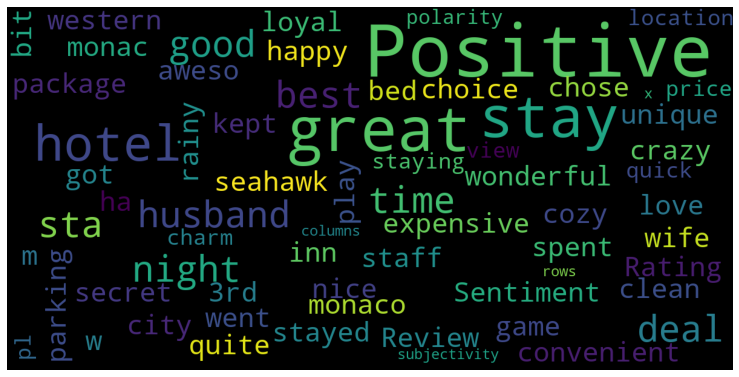

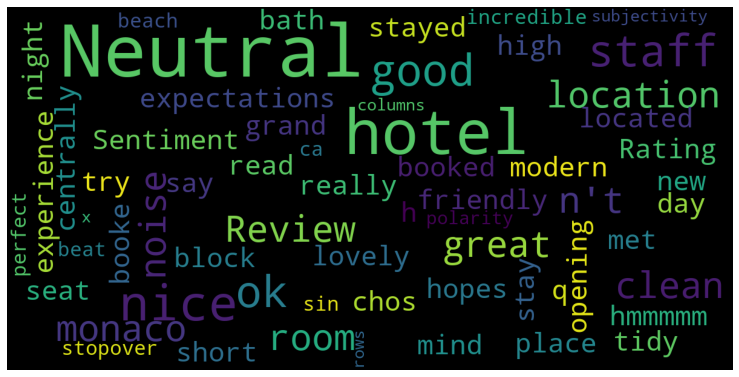

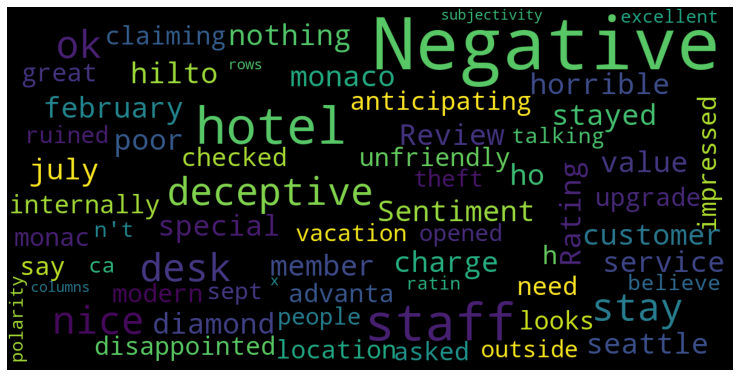

In [38]:
# wordcloud function

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(data, title = None):
    wordcloud = WordCloud(
        background_color = 'black',
        max_words = 100,
        max_font_size = 40, 
        scale = 3,
        random_state = 42
    ).generate(str(data))

    fig = plt.figure(1, figsize = (13, 15))
    plt.axis('off')
    if title: 
        fig.suptitle(title, fontsize = 20)
        fig.subplots_adjust(top = 2.3)

    plt.imshow(wordcloud)
    plt.show()
    
# print wordcloud
show_wordcloud(df_pos)

show_wordcloud(df_neutral)

show_wordcloud(df_neg)

In [39]:
#DATA CLEANING: STOPWORDS AND PUNCTUATIONS REMOVAL
import string
string.punctuation
text_nopunct = ''

text_nopunct = "".join([char for char in text_corpus if char not in string.punctuation])

tokenizer = nltk.tokenize.RegexpTokenizer('\w+')
text_tokens = tokenizer.tokenize(text_nopunct)
len(text_tokens)
text_words = []

# Looping through the tokens and make them lower case
for word in text_tokens:
    text_words.append(word.lower())
stopwords = nltk.corpus.stopwords.words('english')
final_words = []

#Now we need to remove the stop words from the words variable
#Appending to words_new all words that are in words but not in sw

for word in text_words:
    if word not in stopwords:
        final_words.append(word)

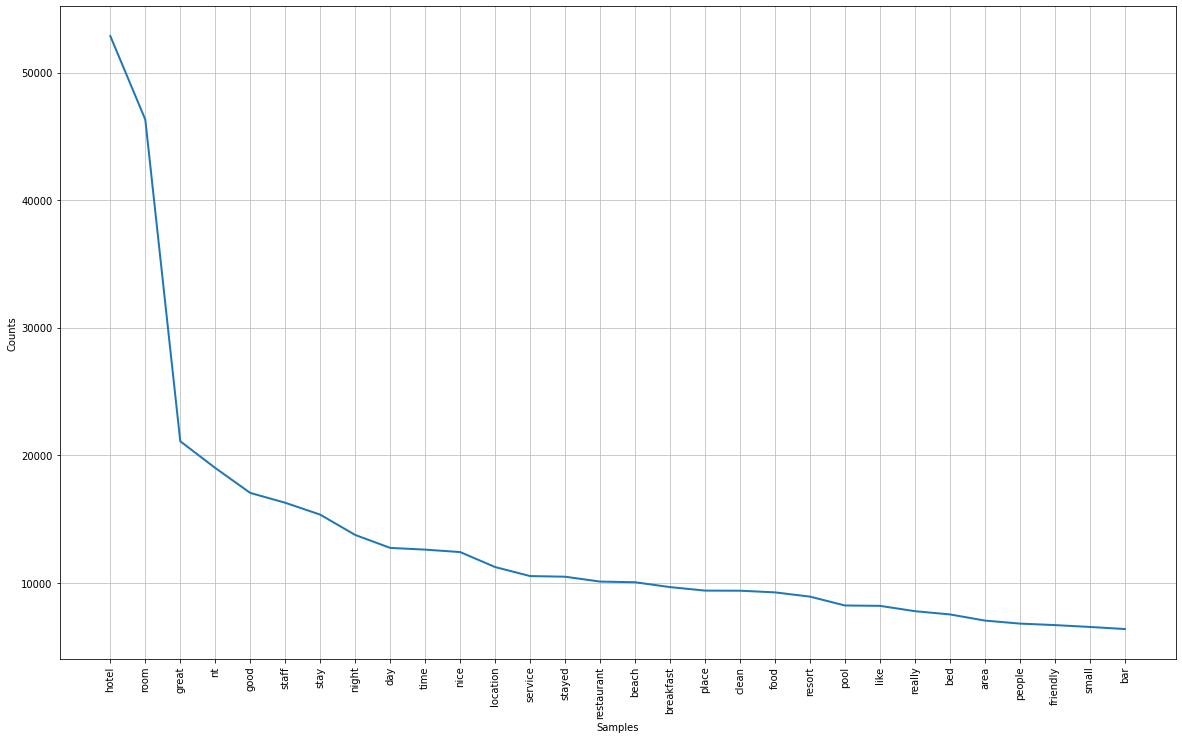

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [40]:
#using WordNetLemmatizer

wn = WordNetLemmatizer()

lem_final_words = []

for word in final_words:
    word = wn.lemmatize(word)
    lem_final_words.append(word)
    
#The frequency distribution of the words
freq_dist_text = nltk.FreqDist(lem_final_words)

#Frequency Distribution Plot
plt.subplots(figsize = (20,12))
freq_dist_text.plot(30)

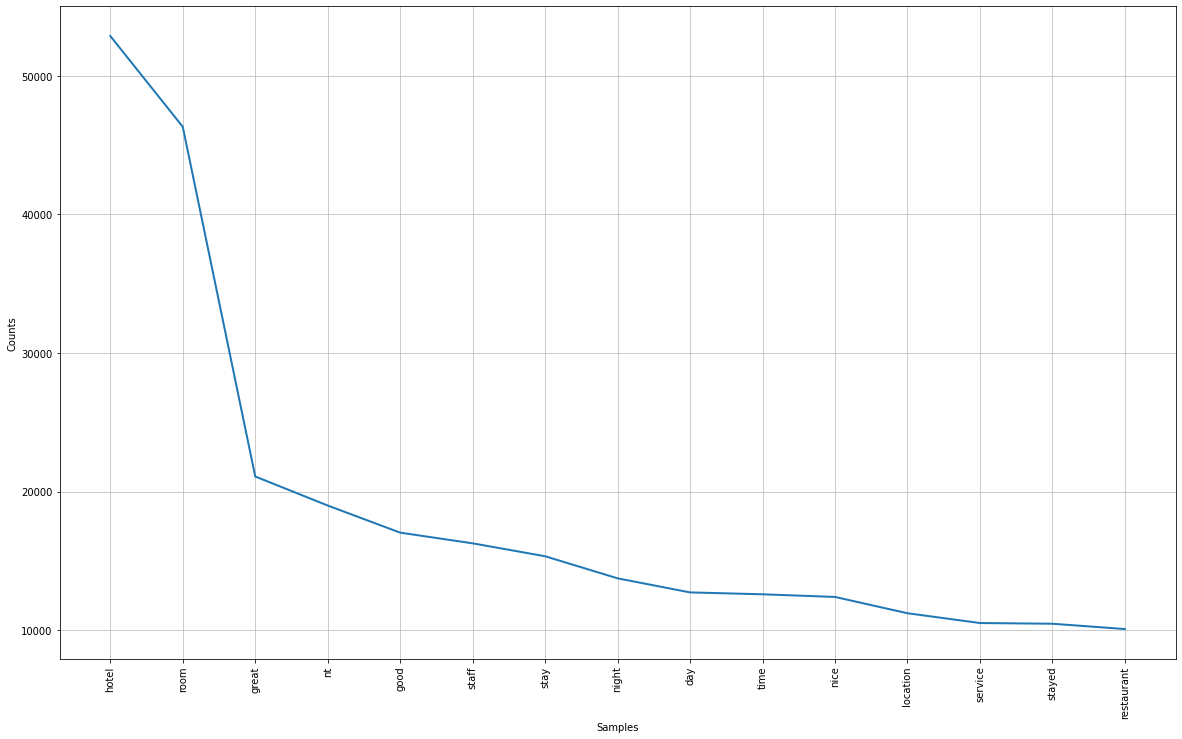

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [41]:
#using WordNetLemmatizer

wn = WordNetLemmatizer()

lem_final_words = []

for word in final_words:
    word = wn.lemmatize(word)
    lem_final_words.append(word)
    
#The frequency distribution of the words
freq_dist_text = nltk.FreqDist(lem_final_words)

#Frequency Distribution Plot
plt.subplots(figsize = (20,12))
freq_dist_text.plot(15)

In [45]:
#From the above graph, we can see some of the words used in the reviews.
#The subset of words used here are selected based on their frequencies.

#48 and 49 were not ran...moves from 39...

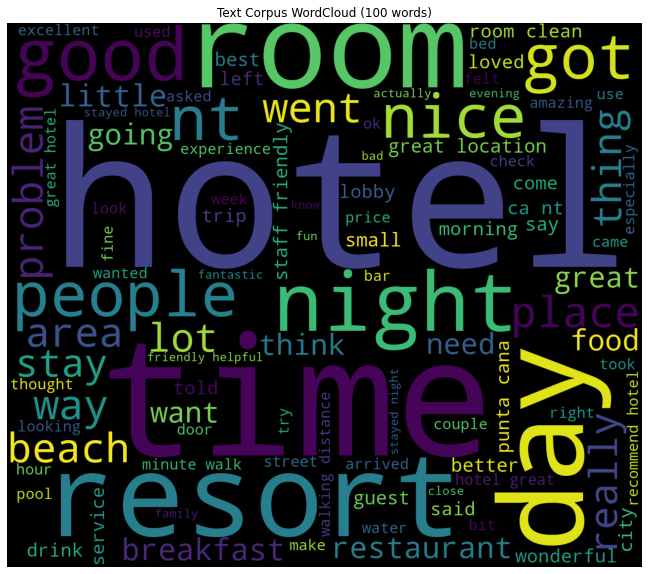

In [46]:
#converting into string

res_text =' '.join([i for i in lem_final_words if not i.isdigit()])

from wordcloud import WordCloud

plt.subplots(figsize = (16,10))
wordcloud = WordCloud(
    background_color = 'black',
    max_words = 100,
    width = 1400,
    height = 1200).generate(res_text)


plt.imshow(wordcloud)
plt.title('Text Corpus WordCloud (100 words)')
plt.axis('off')
plt.show()

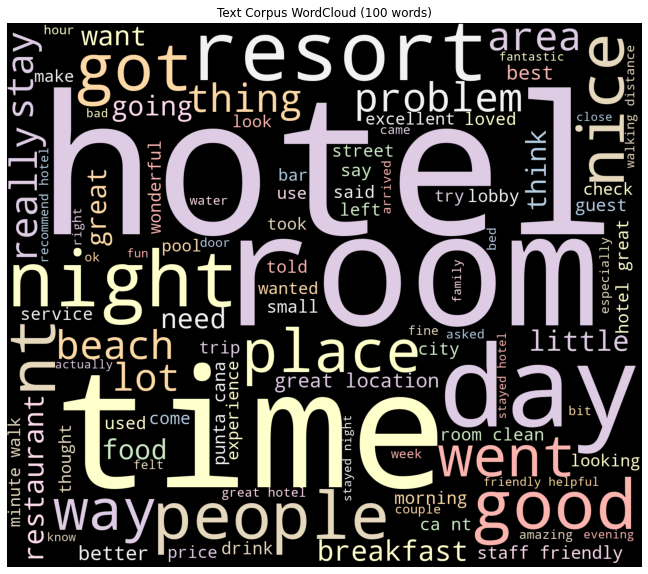

In [47]:
plt.subplots(figsize = (16,10))
wordcloud = WordCloud(
    background_color = 'black', colormap = 'Pastel1',
    max_words = 100,
    width = 1400,
    height = 1200).generate(res_text)

plt.imshow(wordcloud)
plt.title('Text Corpus WordCloud (100 words)')
plt.axis('off')
plt.show()

In [48]:
#RESULTS AND ANALYSIS
df.isna().sum()
sentiments = []
for review in df_all['Review']:
    if TextBlob(review).sentiment.polarity < 3:
        sentiments.append("Negative")
    if TextBlob(review).sentiment.polarity == 3:
        sentiments.append("Neutral")
    if TextBlob(review).sentiment.polarity > 3:
        sentiments.append("Positive")
df["Sentiment"] = np.array(sentiments)

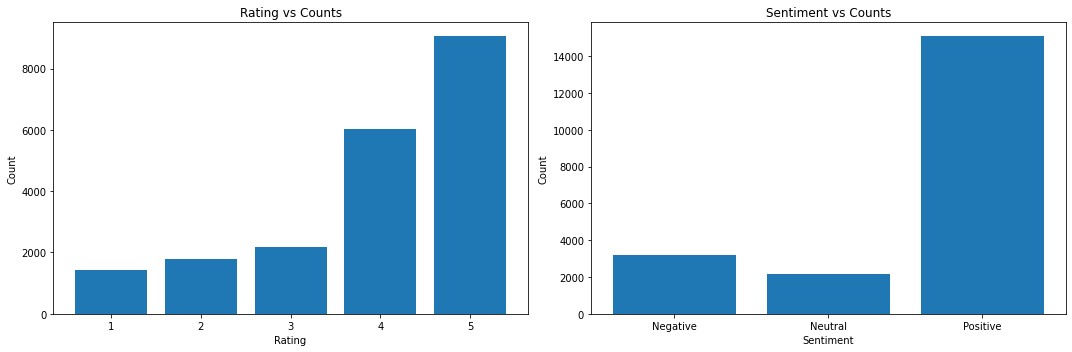

In [49]:
#RESULTS AND ANALYSIS
del sentiments
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
x_axis,counts = np.unique(df_all['Rating'],return_counts=True)
plt.bar([str(i) for i in x_axis],counts)
plt.title("Rating vs Counts")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.subplot(1,2,2)
x_axis,counts = np.unique(df_all['Sentiment'],return_counts=True)
plt.bar(x_axis,counts)
plt.title("Sentiment vs Counts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()

In [50]:
#RESULTS AND ANALYSIS
#RATINGS COUNT ON THE SCALE OF (1-TO-5)
#Ratings and datatype OF THE RATINGS
df["Rating"].value_counts()

5    9054
4    6039
3    2184
2    1793
1    1421
Name: Rating, dtype: int64

In [51]:
#AS THE BAR GRAPHS INDICATES, Majority of the reviews are 4 and 5 RATED,
#Which on the rating frame, both falls under "Posistive Reviews"

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
performance = {'Model' : [],
              'Accuracy Score' : [],
              'Precision Score' : [],
              'Recall Score' : [],
              'f1 Score' : []}

In [53]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(x_train_vec, y_train)
pred = mnb.predict(x_test_vec)

performance['Model'].append('Multinomial NB')
performance['Accuracy Score'].append(accuracy_score(y_test, pred))
performance['Precision Score'].append(precision_score(y_test, pred, average='macro'))
performance['Recall Score'].append(recall_score(y_test, pred, average='macro'))
performance['f1 Score'].append(f1_score(y_test, pred, average='macro'))

In [54]:
from sklearn import svm

clf_svm = svm.SVC(kernel = 'linear')
clf_svm.fit(x_train_vec, y_train)
pred = clf_svm.predict(x_test_vec)

performance['Model'].append('Support Vector Machine')
performance['Accuracy Score'].append(accuracy_score(y_test, pred))
performance['Precision Score'].append(precision_score(y_test, pred, average='macro'))
performance['Recall Score'].append(recall_score(y_test, pred, average='macro'))
performance['f1 Score'].append(f1_score(y_test, pred, average='macro'))

In [55]:
#TABLE CONSTRUCTION FOR THE FINAL MODEL COMPARISON
pd.DataFrame(performance)

,Model,Accuracy Score,Precision Score,Recall Score,f1 Score
0,Multinomial NB,0.847524,0.692134,0.599477,0.594881
1,Support Vector Machine,0.819712,0.649222,0.658493,0.653538


In [56]:
###THE END###